In [ ]:
import os
import re
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt


In [2]:
## get the current working directory
init_cwd = os.getcwd()
cwd_file = [i for i in os.listdir(init_cwd) if 'trans' in i]
os.chdir(cwd_file[0])


In [ ]:
file_list = os.listdir(os.getcwd())

In [7]:
## sepearate files per session
sess1_files = [i for i in file_list if 'session-01' in i]
sess2_files = [i for i in file_list if 'session-02' in i] 
sess3_files = [i for i in file_list if 'session-03' in i]
sess4_files = [i for i in file_list if 'session-04' in i]

In [8]:
def read_sum_data(file_subset):
    df_list = []
    for i in file_subset:
        d = pd.read_csv(i,sep=';')  
        d['sub_num'] = re.search(r'sub-\d{3}', i).group()
        df_list.append(d)
    df_concat = pd.concat(df_list, ignore_index=True)
    return df_concat

In [9]:
sess1_df = read_sum_data(sess1_files)
sess2_df = read_sum_data(sess2_files)
sess3_df = read_sum_data(sess3_files)
sess4_df = read_sum_data(sess4_files)

In [10]:
sess1_df['valence'] = sess1_df['stimuli_name'].apply(lambda x: x.split('_')[0])
sess2_df['valence'] = sess2_df['stimuli_name'].apply(lambda x: x.split('_')[0])
sess3_df['valence'] = sess3_df['stimuli_name'].apply(lambda x: x.split('_')[0])
sess4_df['valence'] = sess4_df['stimuli_name'].apply(lambda x: x.split('_')[0])

In [49]:
sess1_df.to_csv('sess1_allsubs_sumdata.csv', index=False)
sess2_df.to_csv('sess2_allsubs_sumdata.csv', index=False)
sess3_df.to_csv('sess3_allsubs_sumdata.csv', index=False)
sess4_df.to_csv('sess4_allsubs_sumdata.csv', index=False)

<Axes: xlabel='trial', ylabel='probability_condition'>

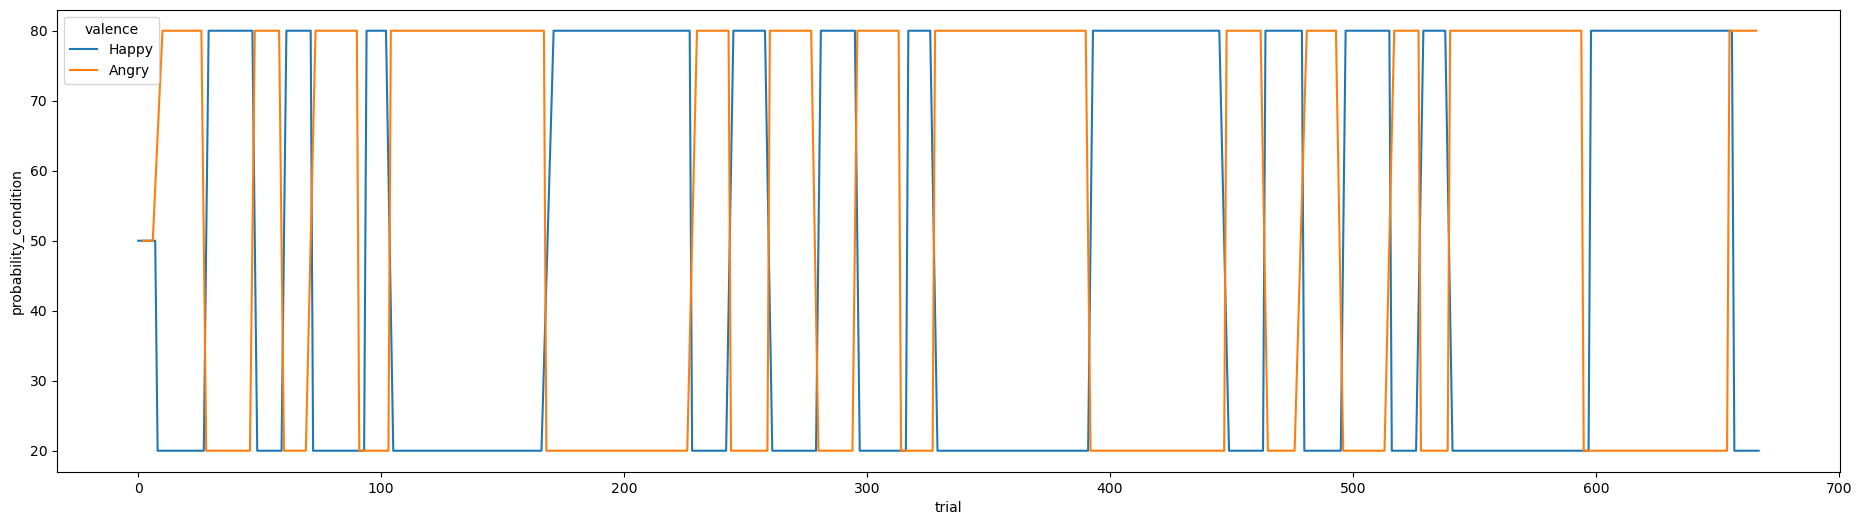

In [ ]:
## plot the trjactory data for session 1
plt.figure(figsize=(23,6))
sns.lineplot(data=sess4_df[sess4_df['sub_num']==sublist[0]], x='trial', y='probability_condition', hue='valence')

<Axes: xlabel='trial', ylabel='accurac'>

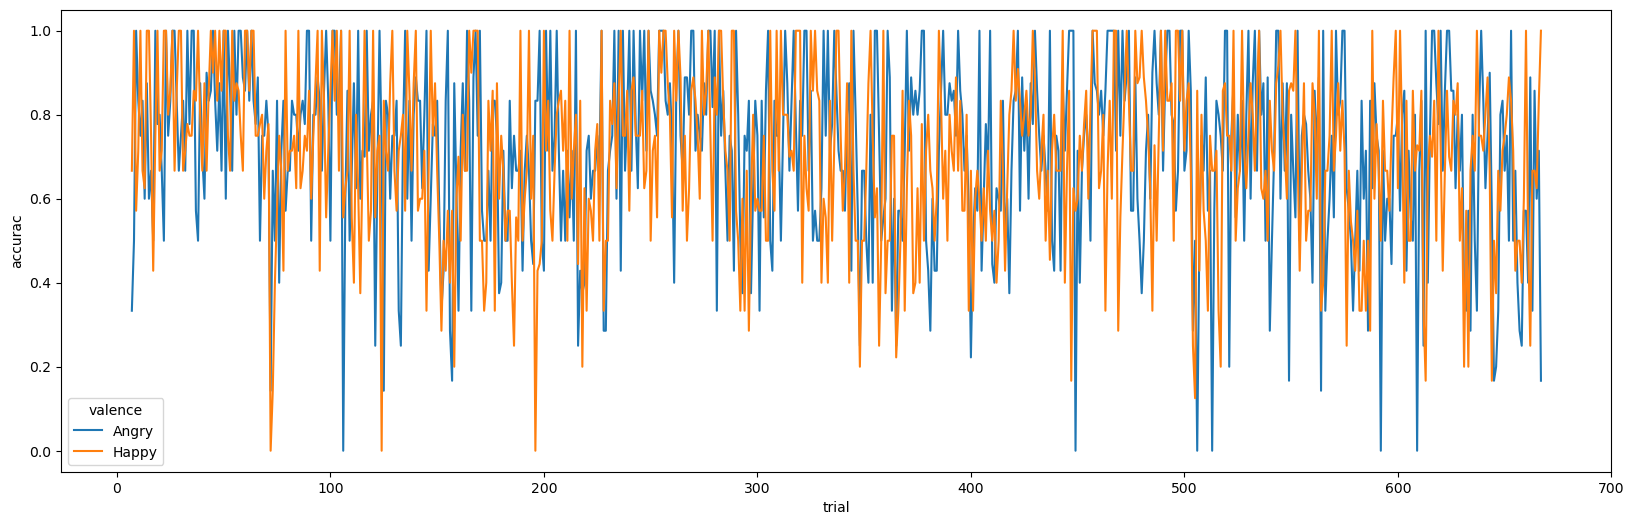

In [20]:
## plot accuracy data for session 1
sess1_df['accurac'] = sess1_df['objectively_correct'].map({'False': 0, 'True': 1,'Even':-1})
sess1_df = sess1_df[sess1_df['accurac'] != -1]
avg = sess1_df.groupby(['trial','valence'])['accurac'].mean().reset_index()
plt.figure(figsize=(20,6))
sns.lineplot(data=avg, x='trial', y='accurac', hue='valence', estimator='mean')


In [ ]:
## detect the reversal
def detect_reversal(df):
    prev_hap_prob = 50
    prev_ang_prob = 50
    reversal_idx_hap = np.zeros(len(df), dtype=bool)
    reversal_idx_ang = np.zeros(len(df), dtype=bool)
    i = 0
    for index, row in df.iterrows():
        current_hap_prob = row['probability_condition'] if row['valence'] == 'Happy' else prev_hap_prob
        current_ang_prob = row['probability_condition'] if row['valence'] == 'Angry' else prev_ang_prob
        
        # Check for reversal
        if prev_hap_prob != current_hap_prob:
            reversal_idx_hap[i] = 1
        if prev_ang_prob != current_ang_prob:
            reversal_idx_ang[i] = 1
        prev_hap_prob = current_hap_prob
        prev_ang_prob = current_ang_prob
        i+=1
    df = df.copy()
    df["reversal_idx_hap"] = reversal_idx_hap
    df["reversal_idx_ang"] = reversal_idx_ang
    return df

sess1_df = sess1_df.groupby('sub_num',group_keys=False).apply(detect_reversal)
sess2_df = sess2_df.groupby('sub_num',group_keys=False).apply(detect_reversal)
sess3_df = sess3_df.groupby('sub_num',group_keys=False).apply(detect_reversal)
sess4_df = sess4_df.groupby('sub_num',group_keys=False).apply(detect_reversal)
    

/var/folders/f9/sl8_xvqx2lxcsvx57mgf6j8r0000gn/T/ipykernel_22113/3330475208.py:26: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sess1_df = sess1_df.groupby('sub_num',group_keys=False).apply(detect_reversal)
/var/folders/f9/sl8_xvqx2lxcsvx57mgf6j8r0000gn/T/ipykernel_22113/3330475208.py:27: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sess2_df = sess2_df.groupby('sub_num',group_keys=False).apply(detect_reversal)
/var

In [ ]:
## classify into volatile and stable phases
def classify_phases(df):
    df = df.copy()

    ## 0 for stable, 1 for volatile
    hap_stab_volt_indx = np.zeros(len(df), dtype=object)
    ang_stab_volt_indx = np.zeros(len(df), dtype=object)

    hap_rev_trials = np.array(df[df['reversal_idx_hap'] == True]['trial'])
    ang_rev_trials = np.array(df[df['reversal_idx_ang'] == True]['trial'])

    start_trial = hap_rev_trials[0]
    for i in hap_rev_trials:
        end_trial = i
        if (end_trial - start_trial) > 50:
            hap_stab_volt_indx[(df['trial'] >= start_trial) & (df['trial'] < end_trial)] = 0
        else:
            hap_stab_volt_indx[(df['trial'] >= start_trial) & (df['trial'] < end_trial)] = 1
        start_trial = end_trial
        
    # Handle the last segment
    if (len(df) - start_trial + 1) > 50:
        hap_stab_volt_indx[(df['trial'] >= start_trial)] = 0
    else:
        hap_stab_volt_indx[(df['trial'] >= start_trial)] = 1

    start_trial = ang_rev_trials[0]
    for i in ang_rev_trials:
        end_trial = i
        if (end_trial - start_trial) > 50:
            ang_stab_volt_indx[(df['trial'] >= start_trial) & (df['trial'] < end_trial)] = 0
        else:
            ang_stab_volt_indx[(df['trial'] >= start_trial) & (df['trial'] < end_trial)] = 1
        start_trial = end_trial
    # Handle the last segment
    if (len(df) - start_trial + 1) > 50:
        ang_stab_volt_indx[(df['trial'] >= start_trial)] = 0
    else:
        ang_stab_volt_indx[(df['trial'] >= start_trial)] = 1

    df['happ_vol_stab'] = hap_stab_volt_indx
    df['ang_vol_stab'] = ang_stab_volt_indx



    return df

sess1_df = sess1_df.groupby('sub_num',group_keys=False).apply(classify_phases)
sess2_df = sess2_df.groupby('sub_num',group_keys=False).apply(classify_phases)
sess3_df = sess3_df.groupby('sub_num',group_keys=False).apply(classify_phases)
sess4_df = sess4_df.groupby('sub_num',group_keys=False).apply(classify_phases)
sess1_df.to_csv('sess1_allsubs_sumdata_rev_phase.csv', index=False)
sess2_df.to_csv('sess2_allsubs_sumdata_rev_phase.csv', index=False)
sess3_df.to_csv('sess3_allsubs_sumdata_rev_phase.csv', index=False)
sess4_df.to_csv('sess4_allsubs_sumdata_rev_phase.csv', index=False)


/var/folders/f9/sl8_xvqx2lxcsvx57mgf6j8r0000gn/T/ipykernel_22113/2858661131.py:47: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sess1_df = sess1_df.groupby('sub_num',group_keys=False).apply(classify_phases)
/var/folders/f9/sl8_xvqx2lxcsvx57mgf6j8r0000gn/T/ipykernel_22113/2858661131.py:48: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sess2_df = sess2_df.groupby('sub_num',group_keys=False).apply(classify_phases)
/var

<Axes: xlabel='trial', ylabel='probability_condition'>

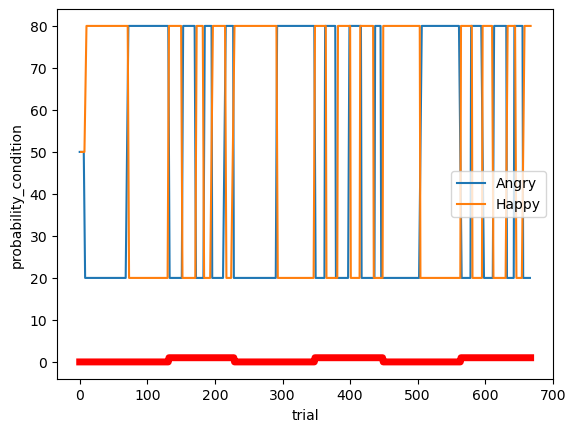

In [ ]:
## check whether the classification is correct
sub_num = 2

sns.lineplot(data=sess3_df[sess3_df['sub_num']==sublist[sub_num]], x='trial', y='probability_condition', hue='valence')
sns.lineplot(data=sess3_df[sess3_df['sub_num']==sublist[sub_num]], x='trial', y='happ_vol_stab',color='red',linewidth=5)